In [9]:
import numpy as np
import gdsfactory as gf

gf.gpdk.PDK.activate()

def rounded_rect_points(width, height, radius, n=40):
    w = width / 2
    h = height / 2
    r = min(radius, w, h)

    centers = [
        (w - r, h - r),
        (-w + r, h - r),
        (-w + r, -h + r),
        (w - r, -h + r),
    ]

    angle_ranges = [
        (0, 90),
        (90, 180),
        (180, 270),
        (270, 360),
    ]

    points = []

    for (cx, cy), (a1, a2) in zip(centers, angle_ranges):
        theta = np.linspace(np.deg2rad(a1), np.deg2rad(a2), n)

        for t in theta:
            points.append(
                (
                    cx + r * np.cos(t),
                    cy + r * np.sin(t),
                )
            )

    return points


def add_text(
    c: gf.Component,
    square_size: float,
    beam_width: float,
    layer=(1, 0),
):
    """Add parameter label under the pattern."""

    label = gf.components.text(
        text=f"L={square_size} W={beam_width}",
        size=40,
        layer=layer,
    )

    label_ref = c << label

    # 放在图案正下方，水平居中
    label_ref.move(
        (
            square_size / 2 - label.xsize / 2,
            -150,
        )
    )
    
        

In [10]:
# 加圆角
def round_inner_corner(
    c: gf.Component, inner_radius, outer_radius, layer=(1, 0)
) -> gf.Component:
    c_out = gf.Component()
    reg = c.get_region(layer=layer, merge=True).rounded_corners(
        r_inner=inner_radius * 1000, r_outer=outer_radius * 1000, n=64
    )
    c_out.add_polygon(reg, layer=layer)
    c_out.add_ref(
        c.extract(
            layers=[l for l in c.layers if gf.get_layer(l) != gf.get_layer(layer)]
        )
    )
    c_out.ports = c.ports
    return c_out

In [11]:
# layer 1: structure layer = square - pattern
# make unit，画一个 和 make_pattern，旋转成四个
@gf.cell
def make_unit(
    outer_width,
    outer_height,
    inner_width,
    inner_height,
    beam_width,
    beam_length,
    overlap,
    layer=(1, 0),
):
    outer = gf.Component()

    # 外圆角矩形
    outer.add_polygon(
        rounded_rect_points(
            width=outer_width,
            height=outer_height,
            radius=outer_height / 2,
        ),
        layer=layer,
    )

    # 上下两根 beam，长度完全相同
    y_positions = [
        outer_height / 2 - overlap,
        -outer_height / 2 - beam_length + overlap,
    ]

    for y in y_positions:
        beam = outer << gf.components.rectangle(
            size=(beam_width, beam_length),
            layer=layer,
        )
        beam.move((-beam_width / 2, y))

    # 内圆角矩形，用来挖空
    inner = gf.Component()
    inner.add_polygon(
        rounded_rect_points(
            width=inner_width,
            height=inner_height,
            radius=inner_height / 2,
        ),
        layer=layer,
    )

    # outer - inner
    unit = gf.boolean(
        A=outer,
        B=inner,
        operation="not",
        layer=layer,
    )

    return unit


# ============================================================
# make_pattern: rotate 4 units around center rectangle
# ============================================================
@gf.cell
def make_pattern(
    square_size=1000,
    beam_width=5,
    layer=(1, 0),
    center_rect_size=100,
):
    c = gf.Component()

    outer_height = 50
    outer_width = 200
    ring_width = beam_width
    overlap = 0.15 * beam_width

    center_half = center_rect_size / 2

    inner_width = outer_width - 2 * ring_width
    inner_height = outer_height - 2 * ring_width

    # ========================================================
    # top beam 和 bottom beam 的长度相同
    #
    # 从中心到外边界：
    # center_half + beam_length + outer_height + beam_length - 2*overlap
    # = square_size / 2
    # ========================================================
    beam_length = (
        square_size / 2
        - center_half
        - outer_height
        + 2 * overlap
    ) / 2

    if beam_length <= 0:
        raise ValueError("square_size is too small.")

    unit = make_unit(
        outer_width=outer_width,
        outer_height=outer_height,
        inner_width=inner_width,
        inner_height=inner_height,
        beam_width=beam_width,
        beam_length=beam_length,
        overlap=overlap,
        layer=layer,
    )

    # bottom beam 的内端
    bottom_center = (
        0,
        -outer_height / 2 - beam_length + overlap,
    )

    # ========================================================
    # 旋转四个 unit
    # 注意：
    # destination=(0, center_half) 只是先平移 unit
    # rotate center=(0, 0) 才是旋转中心
    # ========================================================
    for angle in [0, 90, 180, 270]:
        ref = c << unit

        # 让 bottom beam 的内端接到中心矩形边缘
        ref.move(
            origin=bottom_center,
            destination=(0, center_half),
        )

        # 仍然绕中心矩形的中心旋转
        ref.rotate(
            angle,
            center=(0, 0),
        )

    # 中间矩形
    center_rect = c << gf.components.rectangle(
        size=(center_rect_size, center_rect_size),
        layer=layer,
    )
    center_rect.center = (0, 0)

    return c

# Layer 1: structure layer = square - pattern
@gf.cell
def make_structure_layer(
    square_size=1000,
    beam_width=5,
    layer=(1, 0),
    center_rect_size=100,
):
    """
    Layer 1:
        square - pattern
    """

    # pattern
    pattern = make_pattern(
        square_size=square_size,
        beam_width=beam_width,
        layer=layer,
        center_rect_size=center_rect_size,
    )

    # square
    square = gf.Component()
    square.add_ref(
        gf.components.rectangle(
            size=(square_size, square_size),
            layer=layer,
        )
    ).move((-square_size / 2, -square_size / 2))

    # square - pattern
    structure = gf.boolean(
        A=square,
        B=pattern,
        operation="not",
        layer=layer,
    )

    # move lower-left corner to (0, 0)
    c = gf.Component()
    structure_ref = c << structure
    structure_ref.move(
        origin=(structure.xmin, structure.ymin),
        destination=(0, 0),
    )
    c = round_inner_corner(c, inner_radius=0, outer_radius=10)

    return c

In [12]:
# make_final_structure，包含三层：Layer 1: structure layer = square - pattern; Layer 2: Au; Layer 3: backside KOH etch. 最后加上文本
@gf.cell
def make_final_structure(
    square_size=1000,
    beam_width=5,
    layer=(1, 0),
    center_rect_size=100,
):
    c = gf.Component()

    # ========================================================
    # 1. Layer 1: structure layer
    # ========================================================
    structure = make_structure_layer(
        square_size=square_size,
        beam_width=beam_width,
        layer=layer,
        center_rect_size=center_rect_size,
    )

    structure_ref = c << structure

    # ========================================================
    # 2. Layer 2: Au
    # ========================================================
    Au_layer = (2, 0)
    Au_offset = 2.5
    Au_size = center_rect_size - 2 * Au_offset

    Au_ref = c << gf.components.rectangle(
        size=(Au_size, Au_size),
        layer=Au_layer,
    )

    Au_ref.center = structure_ref.center

    # ========================================================
    # 3. Layer 3: backside KOH etch
    # ========================================================
    backside_layer = (3, 0)
    backside_offset = 371.72
    backside_size = square_size + 2 * backside_offset

    backside_ref = c << gf.components.rectangle(
        size=(backside_size, backside_size),
        layer=backside_layer,
    )

    backside_ref.center = structure_ref.center

    # ========================================================
    # 4. Add text
    # ========================================================
    add_text(
        c=c,
        square_size=square_size,
        beam_width=beam_width,
        layer=layer,
    )

    return c

In [13]:
# backside KOH etch (框)
def backside_koh_etch(
    backside_outer_size: float = 6000,
    order_number="1",
    text_size=20,
    text_margin=1200,   #1650
) -> gf.Component:
    """Create backside KOH pattern with four outer rectangles and WD text on Layer 1."""

    backside_koh_layer = (3, 0)
    text_layer = (1, 0)

    outer_rectangle_width = 375
    outer_rectangle_length = backside_outer_size - outer_rectangle_width - 1200

    if outer_rectangle_length <= 0:
        raise ValueError("backside_outer_size must be larger.")

    c = gf.Component()

    center = (
        (backside_outer_size - outer_rectangle_width) / 2,
        (backside_outer_size - outer_rectangle_width) / 2,
    )

    outer_rectangle = gf.components.rectangle(
        size=(outer_rectangle_length, outer_rectangle_width),
        layer=backside_koh_layer,
    )

    # ============================================================
    # 1. Layer 3: backside KOH frame
    # ============================================================
    for angle in [0, 90, 180, 270]:
        rect_ref = c << outer_rectangle

        rect_ref.x = (backside_outer_size - outer_rectangle_width) / 2
        rect_ref.y = 0

        rect_ref.rotate(
            angle,
            center=center,
        )

    # ============================================================
    # 2. Layer 1: WD text
    # ============================================================
    wd_text = gf.components.text(
        text=f"FT{order_number}",
        size=text_size,
        layer=text_layer,
    )

    # 左上角
    t1 = c << wd_text
    t1.xmin = c.xmin + text_margin
    t1.ymin = c.ymax - text_margin

    # 右上角
    t2 = c << wd_text
    t2.xmax = c.xmax - text_margin
    t2.ymin = c.ymax - text_margin

    # 左下角
    t3 = c << wd_text
    t3.xmin = c.xmin + text_margin
    t3.ymin = c.ymin + text_margin

    # 右下角
    t4 = c << wd_text
    t4.xmax = c.xmax - text_margin
    t4.ymin = c.ymin + text_margin

    return c

In [14]:
# 1. 生成三个 devices：上面两个，下面一个居中
# ============================================================
def make_three_device_array(
    square_size=[1000,2000],
    beam_width=5,
    gap=800,
):
    device_array = gf.Component()

    # ========================================================
    # 生成三个 device
    # ========================================================
    top_left = make_final_structure(
        square_size=square_size[0],
        beam_width=beam_width,
    )

    top_right = make_final_structure(
        square_size=square_size[0],
        beam_width=beam_width,
    )

    bottom = make_final_structure(
        square_size=square_size[1],
        beam_width=beam_width,
    )

    # ========================================================
    # 放入 device_array
    # ========================================================
    r_bottom = device_array << bottom
    r_top_left = device_array << top_left
    r_top_right = device_array << top_right

    # 下面一个
    r_bottom.move((0, 0))

    # 上面两个
    r_top_left.move((0, bottom.ysize + gap))
    r_top_right.move((top_left.xsize + gap, bottom.ysize + gap))

    # 下面一个居中到上面两个整体中心
    r_bottom.center = (
        (r_top_left.xmin + r_top_right.xmax) / 2,
        r_bottom.center[1],
    )

    return device_array


# ============================================================
# 2. 加 backside KOH，并让整体居中
# ============================================================
def cell_frame_ten(
    square_size=[1000,2000],
    beam_width=5,
    gap=700,
    backside_outer_size=7300,
    order_number="1",
):
    c = gf.Component()

    device_array = make_three_device_array(
        square_size=square_size,
        beam_width=beam_width,
        gap=gap,
    )

    backside = backside_koh_etch(
        backside_outer_size=backside_outer_size,
        order_number=order_number,
    )

    backside_ref = c << backside
    device_array_ref = c << device_array

    # 让三个 device 整体 center 对齐 backside KOH 的 center
    device_array_ref.center = backside_ref.center

    # 让最终 cell_frame_ten 的 center 在 (0, 0)
    c.move(origin=c.center, destination=(0, 0))
    
    return c

In [15]:
# comsol 用的单层 GDS
def export_comsol_gds(
    square_size=1000,
    beam_width=5,
    layer=(1, 0),
    center_rect_size=100,
    frame_width=20,
    filename="comsol_input.gds",
):
    pattern = make_pattern(
        square_size=square_size,
        beam_width=beam_width,
        layer=layer,
        center_rect_size=center_rect_size,
    )

    # 外框尺寸
    outer_size = square_size + 2 * frame_width

    # 外正方形
    outer = gf.Component()
    outer << gf.components.rectangle(
        size=(outer_size, outer_size),
        layer=layer,
    )

    # 内部挖空正方形
    inner = gf.Component()
    inner_ref = inner << gf.components.rectangle(
        size=(square_size, square_size),
        layer=layer,
    )
    inner_ref.move((frame_width, frame_width))

    # frame = outer - inner
    frame = gf.boolean(
        A=outer,
        B=inner,
        operation="not",
        layer=layer,
    )

    # 合并 pattern + frame
    c = gf.Component("comsol_input")

    frame_ref = c << frame
    pattern_ref = c << pattern

    # pattern 和 frame 中心对齐
    pattern_ref.center = frame_ref.center

    c.flatten()
    c = round_inner_corner(c, inner_radius=10, outer_radius=0)
    c.plot()
    c.show()
    c.write_gds(filename, with_metadata=False)

    return c

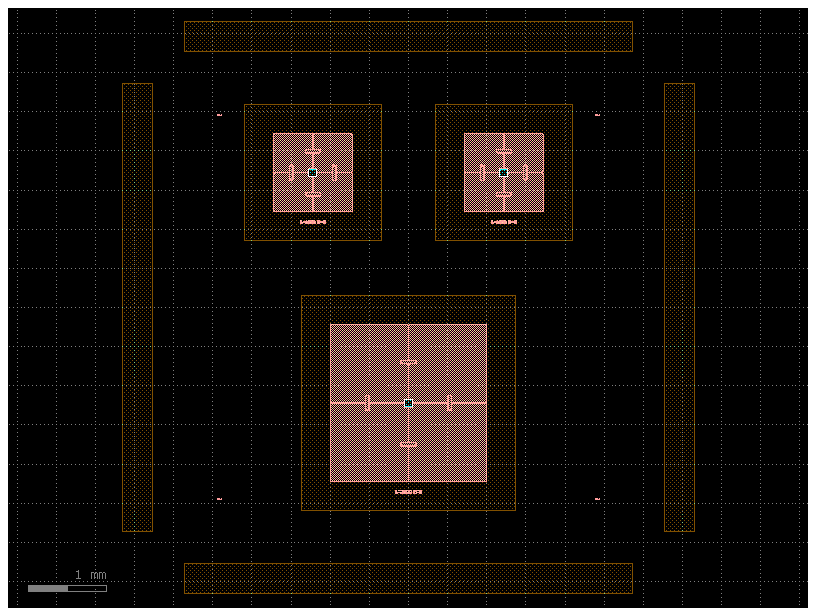

In [16]:
if __name__ == "__main__":
    gf.clear_cache()

    square_size=[1000,2000]
    beam_width = 5
    i = 1
    j = 1
    c = cell_frame_ten(order_number=f'{i}_{j}', beam_width=beam_width, square_size=square_size)
    # c = cell_frame_ten(
    #     square_size=square_size,
    #     beam_width=beam_width,
    #     text="FT" + str(beam_width),
    # )

    c.plot()
    c.show()

    # 是否导出 COMSOL 用的单层 GDS
    export_comsol = False  # True or False

    if export_comsol:
        export_comsol_gds(
           square_size=square_size,
           beam_width=beam_width,
           frame_width=10,
        )